In [24]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_by_session,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    odor_colors,
)
from aux_funcs import format_plot
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

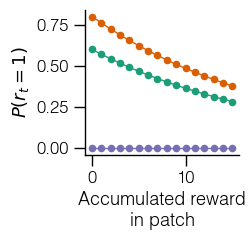

In [26]:
# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.6,  0.8]   # one per curve
decay_rates = [1,  1/20,  1/20]   # one per curve

x = np.arange(16)   # 0 through 20

fig, ax = plt.subplots(figsize=(2.5, 2.5))
for prefactor, decay_rate, color in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    ax.plot(x, y, color=color, lw=1)
    ax.scatter(x, y, color=color, s=20)
ax.set_xlabel('Accumulated reward\nin patch')
ax.set_ylabel(r'$P(r_t=1)$')
format_plot(ax)
plt.tight_layout()
plt.show()

In [27]:
FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS = [
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_net0/trajectories_20260420_123505.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_net1/trajectories_20260420_131025.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_net2/trajectories_20260420_134543.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_net3/trajectories_20260420_142059.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_net4/trajectories_20260420_145616.pkl',
]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f6afa00b090>>
Traceback (most recent call last):
  File "/home/david.bell/anaconda3/envs/favorably_connected/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


[21.  0.  0.  0.  0.  2.  8.  6.  1.  2.  1.  0.  2.  5.  1.  3.  3.  4.
  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 67. 102.  99.  93.  86. 107.  93.  60.  23.   9.   7.   3.   2.   1.
   3.   3.   4.   0.   1.   0.   0.   0.   0.   0.   1.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
[ 66. 102.  99.  92.  85. 102.  77.  42.  17.   6.   4.   3.   2.   1.
   2.   3.   4.   0.   1.   0.   0.   0.   0.   0.   1.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
[ 27.  63.  68.  77.  73.  78.  98. 111.  89.  96. 103.  82. 107.  96.
  89.  66.  44.  22.  12.   6.   2.   5.   8.   5.   7.   1.   1.   1.
   2.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
[ 27.  63.  68.  76.  73.  78.  98. 111.  89.  95. 103.  82. 104.  89.
  84.  53.  34.  17.   8.   6.

<string>:76: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


[26.  1.  0.  1.  1.  0.  5.  8.  5.  3.  1.  1.  0.  1.  3.  4.  3.  3.
  0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[56. 92. 88. 91. 93. 81. 81. 57. 26. 21.  4.  6.  4.  2.  0.  3.  1.  4.
  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.]
[56. 91. 87. 90. 91. 77. 68. 45. 21. 12.  3.  5.  3.  2.  0.  3.  1.  4.
  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.]
[ 32.  58.  58.  59.  84.  87.  85.  92. 102.  91.  86. 102.  86. 118.
  94.  97.  58.  39.  21.  15.   5.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
[ 32.  58.  58.  59.  84.  87.  85.  92. 101.  91.  86. 100.  84. 115.
  89.  88.  51.  29.  19.  10.   3.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0

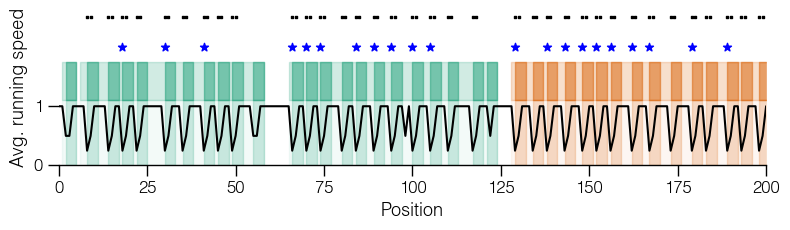

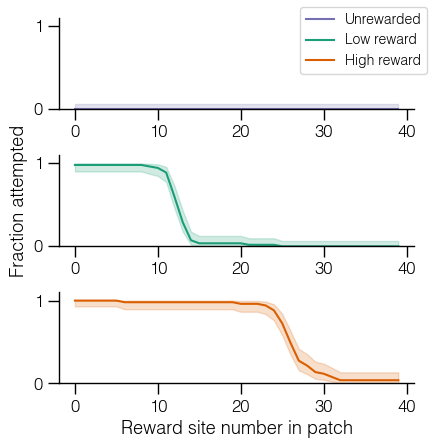

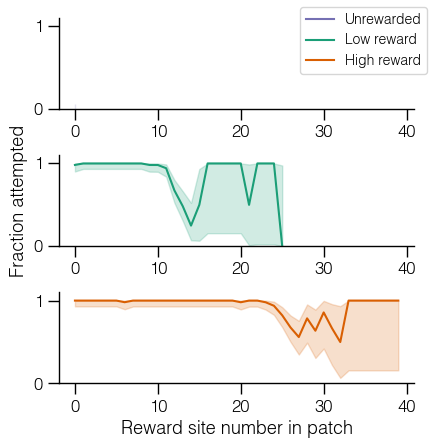

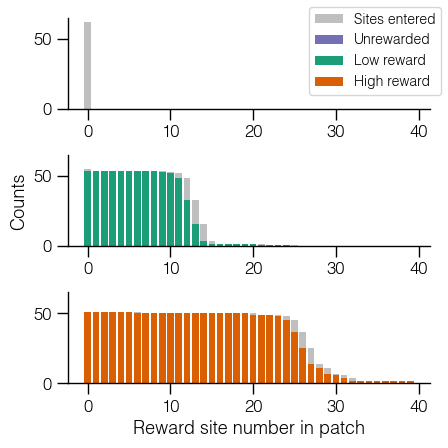

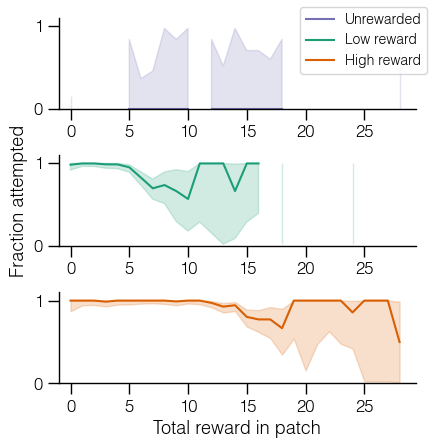

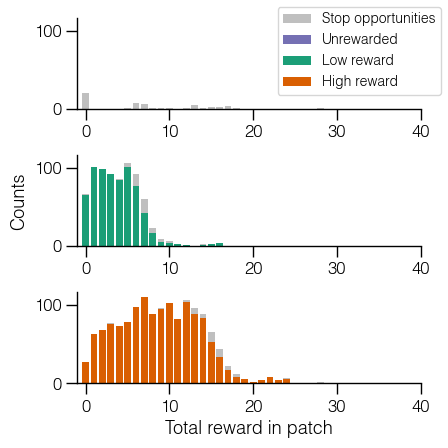

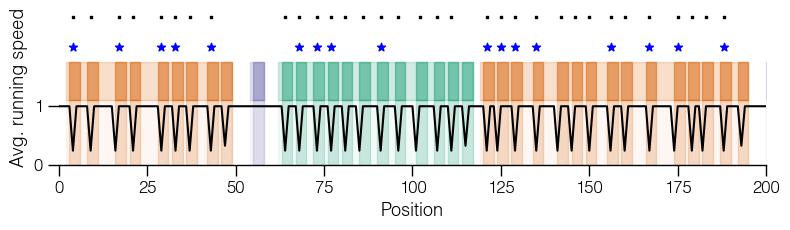

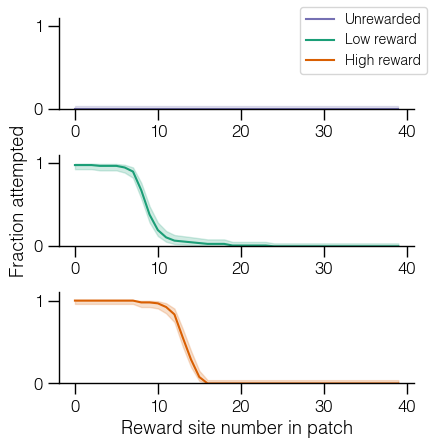

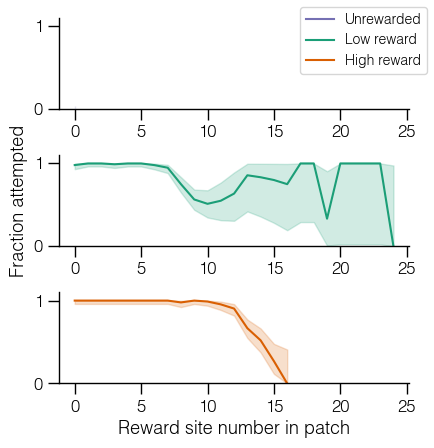

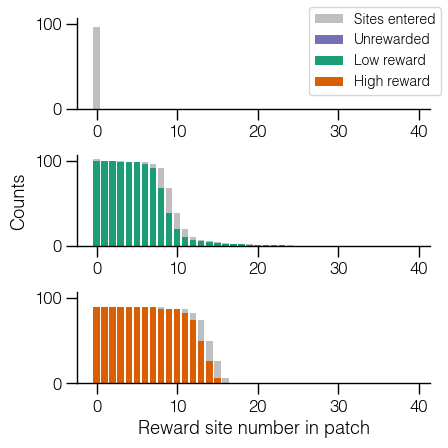

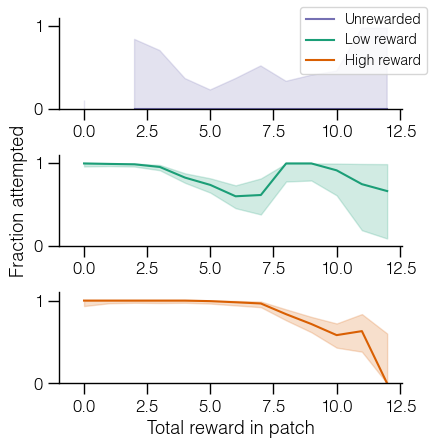

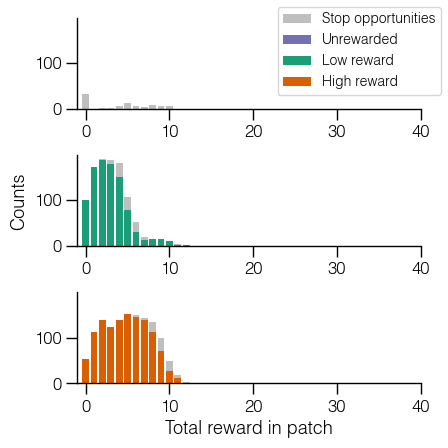

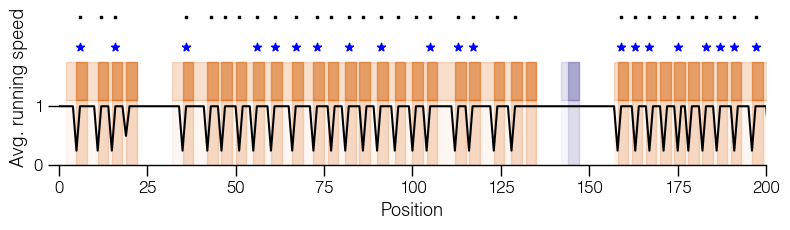

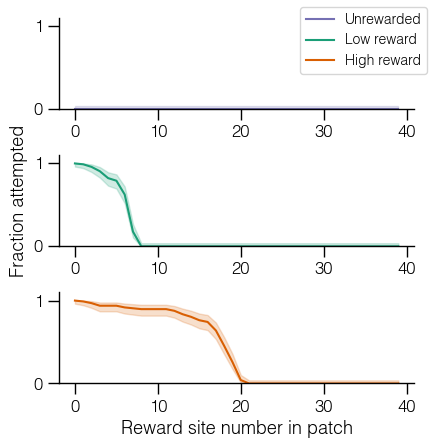

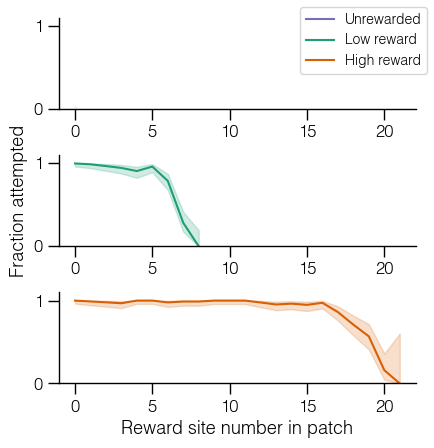

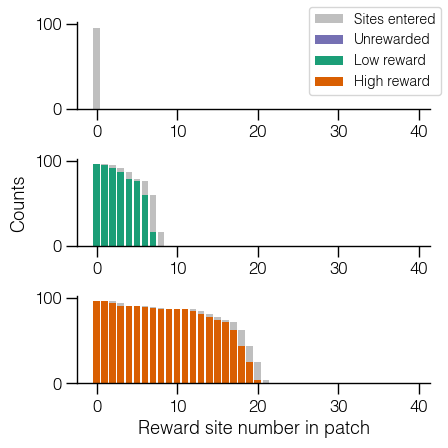

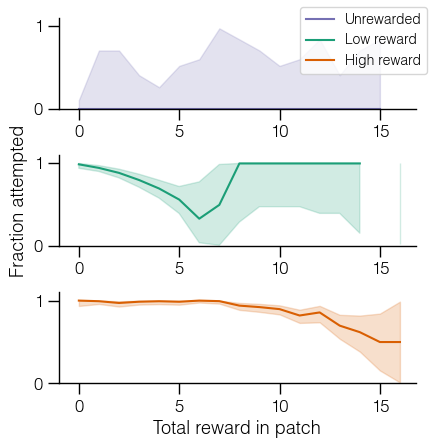

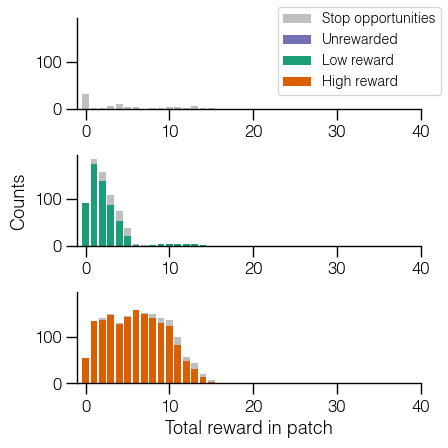

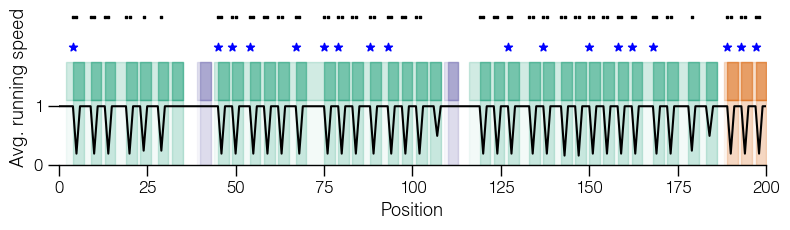

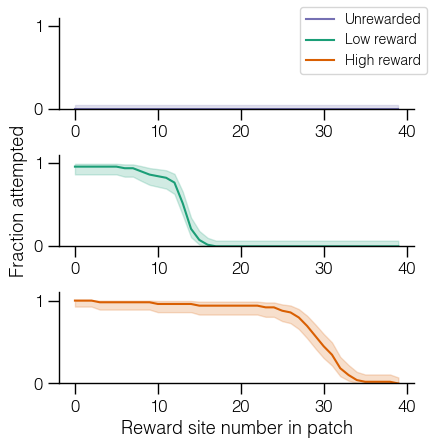

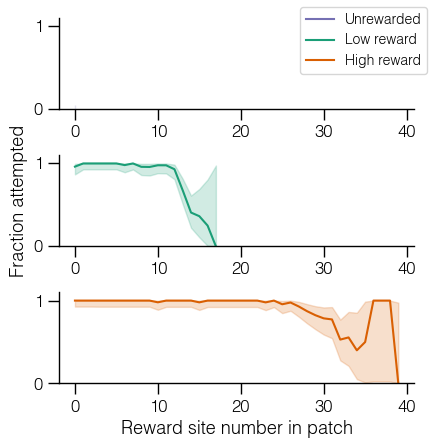

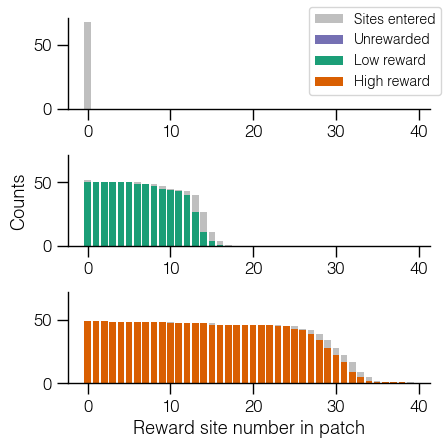

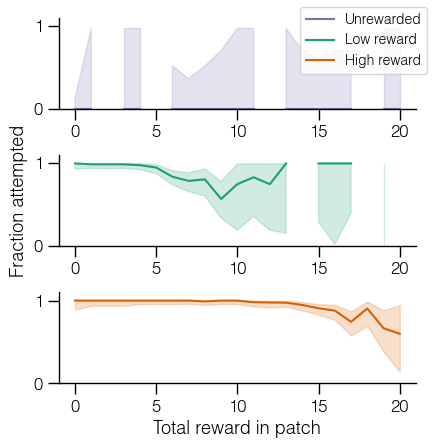

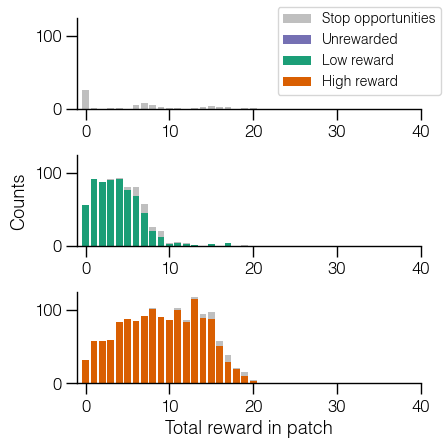

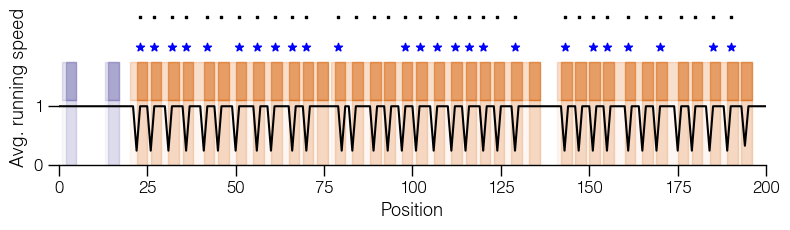

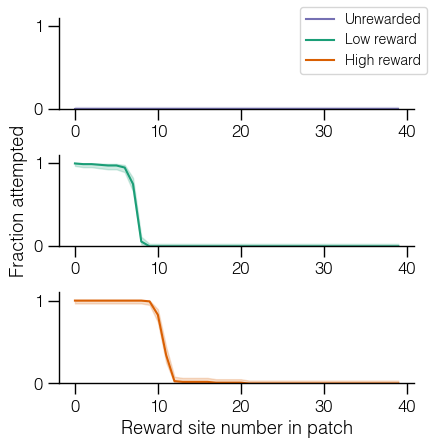

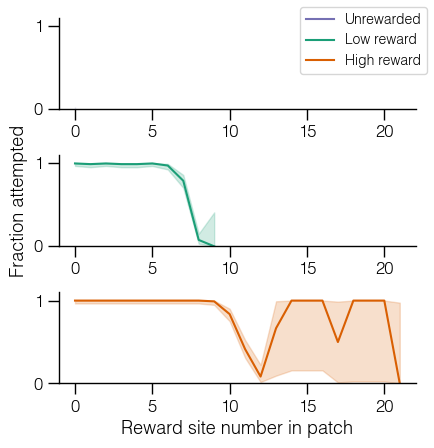

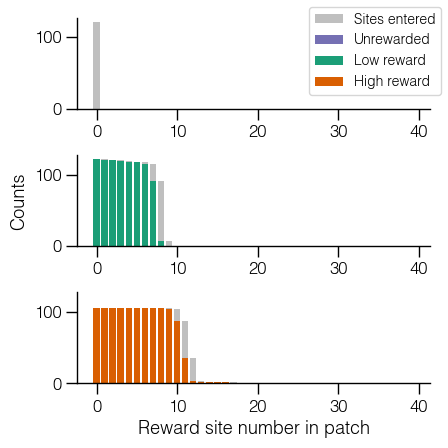

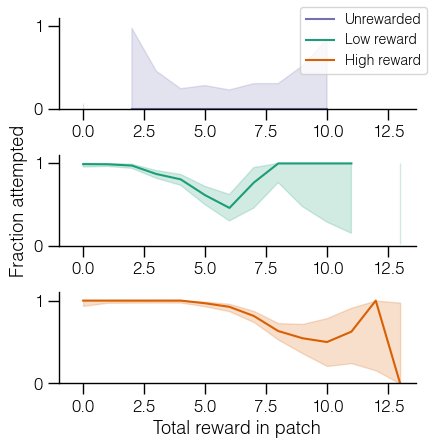

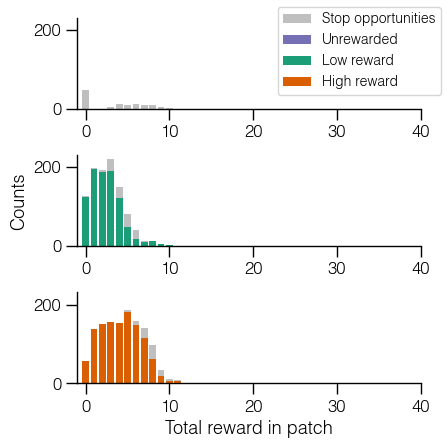

In [28]:
for i, data_path in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS):
    plot_session(data_path, session_idx=0, xlim=(0, 200), max_reward_param=40, max_reward_sites=30, use_fixed_colors=True, save_dir=f'../../../figures/gru_fixed_exp_offset_net_{i}')

In [ ]:
dfs = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='rewards_collected', order=taus,
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='reward_prob', order=taus,


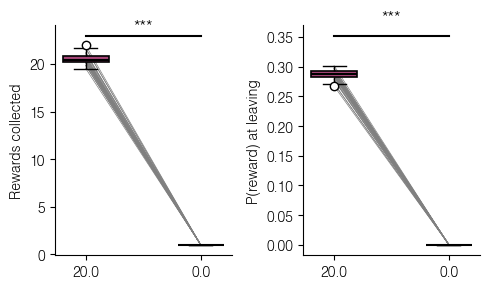

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='rewards_collected', order=taus,
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='reward_prob', order=taus,


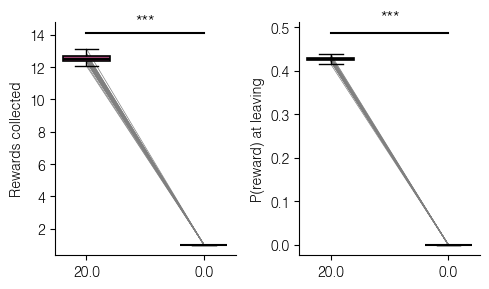

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='rewards_collected', order=taus,
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='reward_prob', order=taus,


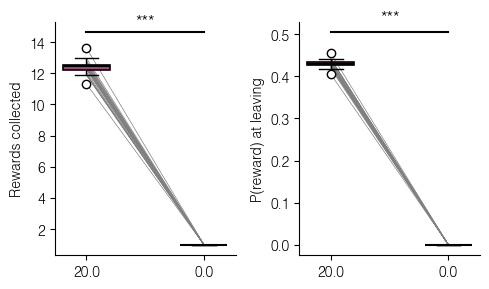

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='rewards_collected', order=taus,
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='reward_prob', order=taus,


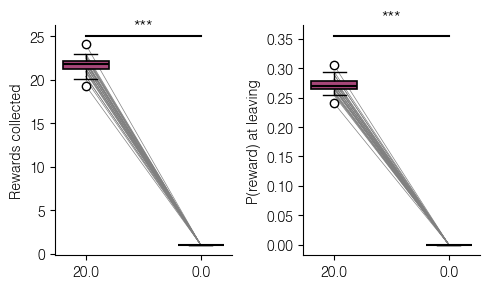

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='rewards_collected', order=taus,
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary_df, x='tau', y='reward_prob', order=taus,


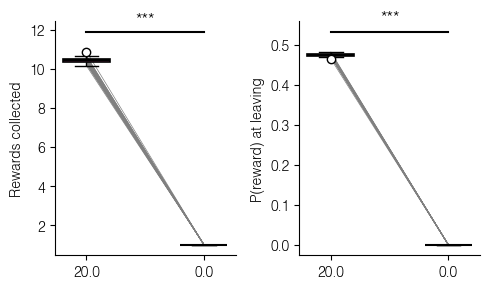

In [ ]:
for df in dfs:
    plot_patch_statistics_by_session(df)

In [ ]:
# fig = plot_patch_statistics(pd.concat(dfs))
# savefig(fig, '../../figures/offset_networks_mvp_plots')

Processing GRU (offset)...
Processing GRU (offset)...
Processing GRU (offset)...
Processing GRU (offset)...
Processing GRU (offset)...


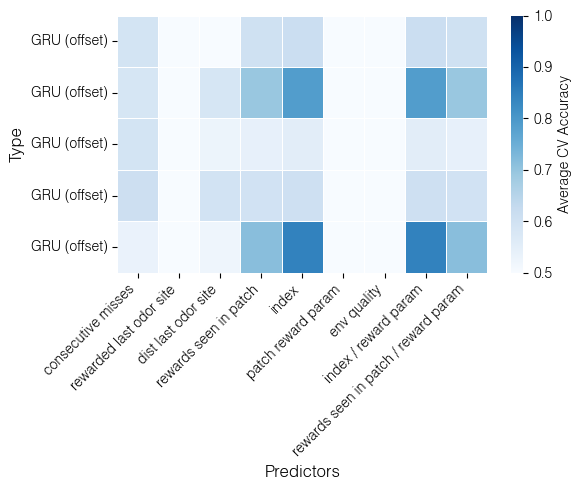

In [ ]:
plot_multi_df_accuracy_heatmap(
    [df[df['index'] > 0] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    df_labels=['GRU (offset)'] * len(dfs),
    figsize=(6, 5),
)

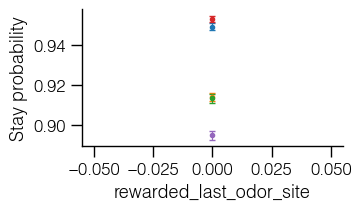

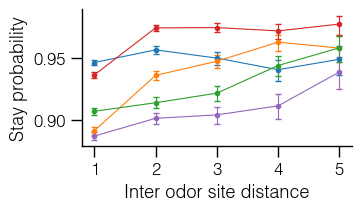

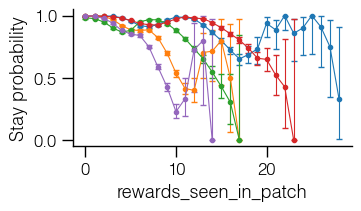

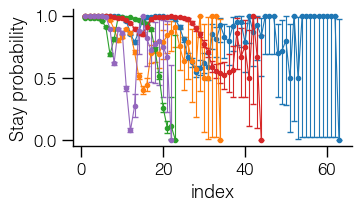

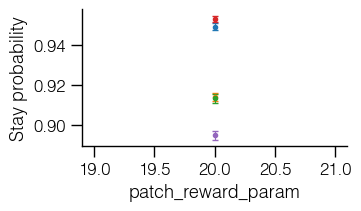

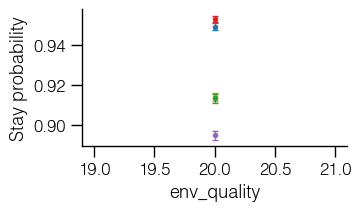

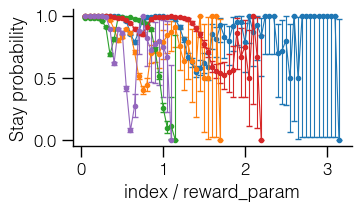

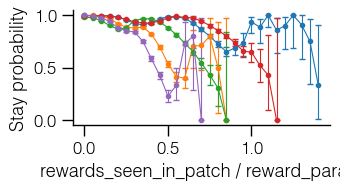

In [ ]:
plot_leave_probabilities(
    [df[df['index'] > 0] for df in dfs],
    [
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

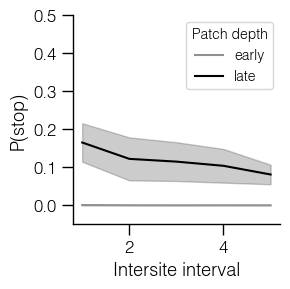

In [ ]:
fig = plot_grouped_mean_std(
    append_index_phase(pd.concat([df[df['index'] > 0] for df in dfs])),
    'dist_last_odor_site',
    'segment',
    'stopped',
    'network_num',
)
savefig(fig, '../../figures/offset_intersite_interval_early_late')

In [ ]:
dfs[0].columns

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'consecutive_misses', 'rewarded_1', 'rewarded_2', 'rewarded_3',
       'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7', 'rewarded_8',
       'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarded_45', 'reward

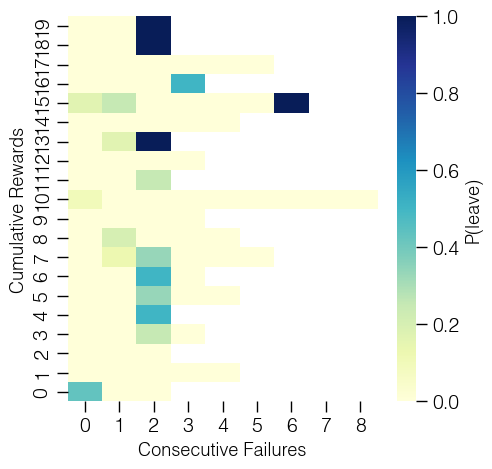

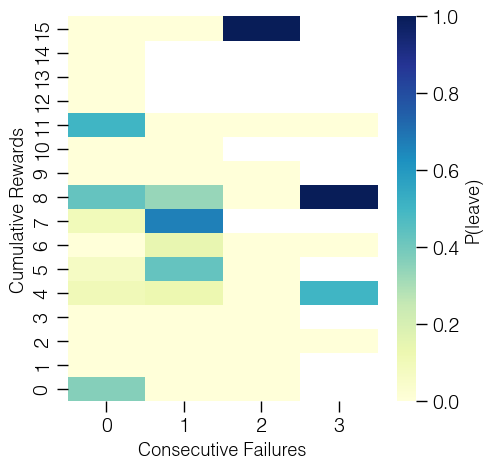

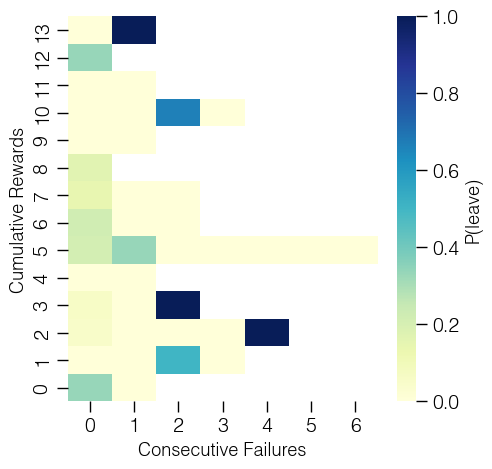

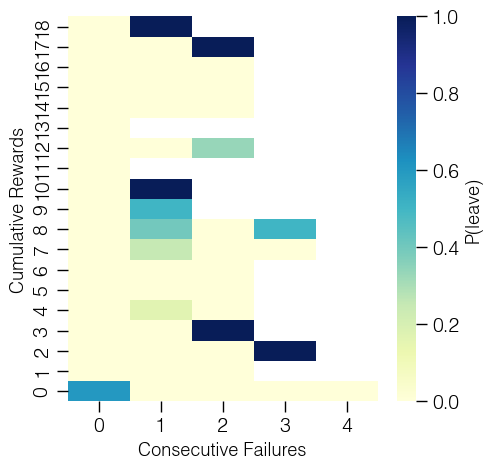

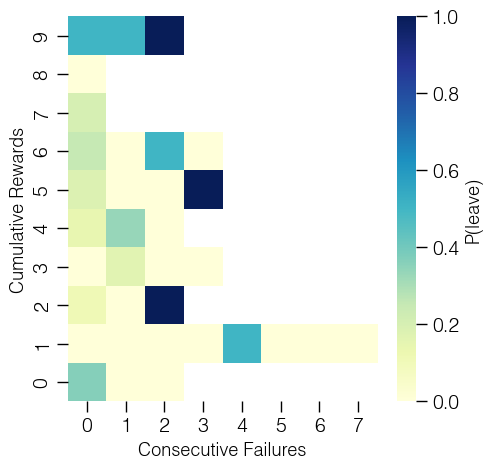

In [ ]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_number'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
    )
None

In [ ]:
dfs[0].columns

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'consecutive_misses', 'rewarded_1', 'rewarded_2', 'rewarded_3',
       'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7', 'rewarded_8',
       'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarded_45', 'reward

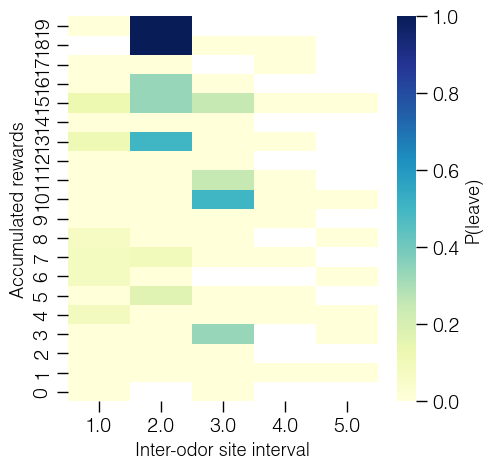

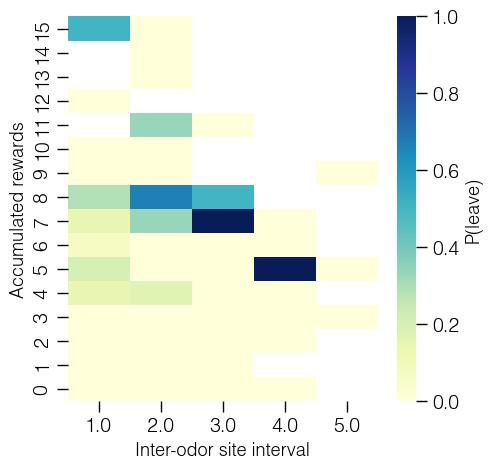

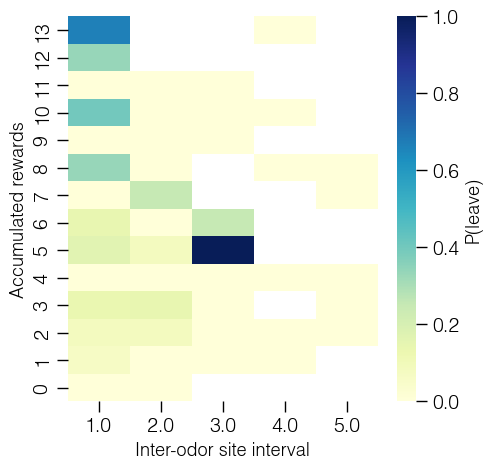

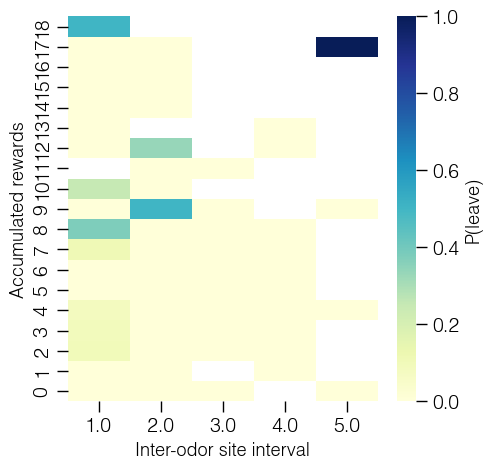

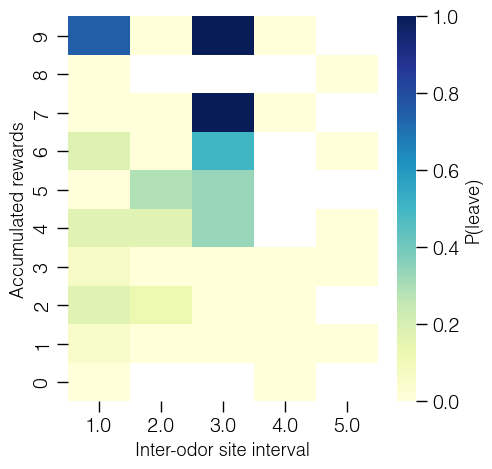

In [ ]:
for df in dfs:
    plot_stop_fraction(
        df,
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_number'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Inter-odor site interval',
        ylabel='Accumulated rewards',
    )
None